In [1]:
# ============================================================
# CHRONIC KIDNEY DISEASE (CKD) CLASSIFICATION
# Machine Learning Classification Assignment
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Binarizer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import CategoricalNB
from sklearn.naive_bayes import ComplementNB

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

In [2]:
# ============================================================
# 2. READ DATASET
# ============================================================
# Change the file name according to your dataset
dataset = pd.read_csv("CKD.csv")
# Display the dataset
dataset

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,2.000000,76.459948,c,3.0,0.0,normal,abnormal,notpresent,notpresent,148.112676,...,38.868902,8408.191126,4.705597,no,no,no,yes,yes,no,yes
1,3.000000,76.459948,c,2.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,34.000000,12300.000000,4.705597,no,no,no,yes,poor,no,yes
2,4.000000,76.459948,a,1.0,0.0,normal,normal,notpresent,notpresent,99.000000,...,34.000000,8408.191126,4.705597,no,no,no,yes,poor,no,yes
3,5.000000,76.459948,d,1.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,38.868902,8408.191126,4.705597,no,no,no,yes,poor,yes,yes
4,5.000000,50.000000,c,0.0,0.0,normal,normal,notpresent,notpresent,148.112676,...,36.000000,12400.000000,4.705597,no,no,no,yes,poor,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,51.492308,70.000000,a,0.0,0.0,normal,normal,notpresent,notpresent,219.000000,...,37.000000,9800.000000,4.400000,no,no,no,yes,poor,no,yes
395,51.492308,70.000000,c,0.0,2.0,normal,normal,notpresent,notpresent,220.000000,...,27.000000,8408.191126,4.705597,yes,yes,no,yes,poor,yes,yes
396,51.492308,70.000000,c,3.0,0.0,normal,normal,notpresent,notpresent,110.000000,...,26.000000,9200.000000,3.400000,yes,yes,no,poor,poor,no,yes
397,51.492308,90.000000,a,0.0,0.0,normal,normal,notpresent,notpresent,207.000000,...,38.868902,8408.191126,4.705597,yes,yes,no,yes,poor,yes,yes


In [3]:
# ============================================================
# 3. BASIC INFORMATION ABOUT DATASET
# ============================================================

# Number of rows and columns
print("Total number of rows:", dataset.shape[0])
print("Total number of columns:", dataset.shape[1])

# Dataset information
print("\nDataset Information:")
print(dataset.info())

# First 5 rows
print("\nFirst 5 rows:")
print(dataset.head())

# Statistical information
print("\nStatistical Information:")
print(dataset.describe(include="all"))

Total number of rows: 399
Total number of columns: 25

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             399 non-null    float64
 1   bp              399 non-null    float64
 2   sg              399 non-null    object 
 3   al              399 non-null    float64
 4   su              399 non-null    float64
 5   rbc             399 non-null    object 
 6   pc              399 non-null    object 
 7   pcc             399 non-null    object 
 8   ba              399 non-null    object 
 9   bgr             399 non-null    float64
 10  bu              399 non-null    float64
 11  sc              399 non-null    float64
 12  sod             399 non-null    float64
 13  pot             399 non-null    float64
 14  hrmo            399 non-null    float64
 15  pcv             399 non-null    float64
 16  wc  

In [4]:
# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(dataset.isnull().sum())


Missing Values:
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hrmo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [5]:
# ============================================================
# 5. SEPARATE INDEPENDENT AND DEPENDENT VARIABLES
# ============================================================

# Target variable
dependent = dataset["classification"]

# Independent variables
independent = dataset.drop("classification", axis=1)

print("\nIndependent Variables:")
print(independent.head())

print("\nDependent Variable:")
print(dependent.head())


Independent Variables:
   age         bp sg   al   su     rbc        pc         pcc          ba  \
0  2.0  76.459948  c  3.0  0.0  normal  abnormal  notpresent  notpresent   
1  3.0  76.459948  c  2.0  0.0  normal    normal  notpresent  notpresent   
2  4.0  76.459948  a  1.0  0.0  normal    normal  notpresent  notpresent   
3  5.0  76.459948  d  1.0  0.0  normal    normal  notpresent  notpresent   
4  5.0  50.000000  c  0.0  0.0  normal    normal  notpresent  notpresent   

          bgr  ...       hrmo        pcv            wc        rc  htn  dm  \
0  148.112676  ...  12.518156  38.868902   8408.191126  4.705597   no  no   
1  148.112676  ...  10.700000  34.000000  12300.000000  4.705597   no  no   
2   99.000000  ...  12.000000  34.000000   8408.191126  4.705597   no  no   
3  148.112676  ...   8.100000  38.868902   8408.191126  4.705597   no  no   
4  148.112676  ...  11.800000  36.000000  12400.000000  4.705597   no  no   

   cad  appet    pe  ane  
0   no    yes   yes   no  
1 

In [6]:
# ============================================================
# 6. CONVERT CATEGORICAL DATA TO NOMINAL DATA
# ============================================================

# Convert categorical columns into dummy variables
independent = pd.get_dummies(
    independent,
    drop_first=True
)

print("\nDataset after converting categorical data to nominal data:")
print(independent.head())

print("\nNumber of independent variables after encoding:",
      independent.shape[1])


Dataset after converting categorical data to nominal data:
   age         bp   al   su         bgr         bu        sc         sod  \
0  2.0  76.459948  3.0  0.0  148.112676  57.482105  3.077356  137.528754   
1  3.0  76.459948  2.0  0.0  148.112676  22.000000  0.700000  137.528754   
2  4.0  76.459948  1.0  0.0   99.000000  23.000000  0.600000  138.000000   
3  5.0  76.459948  1.0  0.0  148.112676  16.000000  0.700000  138.000000   
4  5.0  50.000000  0.0  0.0  148.112676  25.000000  0.600000  137.528754   

        pot       hrmo  ...  rbc_normal  pc_normal  pcc_present  ba_present  \
0  4.627244  12.518156  ...        True      False        False       False   
1  4.627244  10.700000  ...        True       True        False       False   
2  4.400000  12.000000  ...        True       True        False       False   
3  3.200000   8.100000  ...        True       True        False       False   
4  4.627244  11.800000  ...        True       True        False       False   

   htn_y

In [7]:
# ============================================================
# 7. CONVERT TARGET VARIABLE INTO NUMERICAL FORMAT
# ============================================================

# Convert target values such as yes/no or ckd/notckd
# into numerical values
le = LabelEncoder()

dependent = le.fit_transform(
    dependent.astype(str).str.strip().str.lower()
)

print("\nTarget classes:")
print(le.classes_)

print("\nEncoded dependent variable:")
print(dependent[:10])



Target classes:
['no' 'yes']

Encoded dependent variable:
[1 1 1 1 1 1 1 1 1 1]


In [8]:
# ============================================================
# 8. SPLIT INTO TRAINING SET AND TEST SET
# ============================================================

x_train, x_test, y_train, y_test = train_test_split(
    independent,
    dependent,
    test_size=1/3,
    random_state=0,
    stratify=dependent
)

print("\nTraining data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


Training data shape: (266, 27)
Testing data shape: (133, 27)


In [9]:
# ============================================================
# 9. CREATE RESULT TABLE
# ============================================================

model_results = []

In [10]:
# ============================================================
# 10. FUNCTION FOR MODEL EVALUATION
# ============================================================

def evaluate_model(model_name, grid, x_test, y_test):

    # Prediction
    y_pred = grid.predict(x_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\n===================================================")
    print(model_name)
    print("===================================================")

    print("\nBest Parameters:")
    print(grid.best_params_)

    print("\nBest Cross Validation Score:")
    print(grid.best_score_)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # Precision
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Recall
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Weighted F1
    f1_weighted = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # ROC-AUC
    try:

        if hasattr(grid, "predict_proba"):

            y_probability = grid.predict_proba(
                x_test
            )[:, 1]

            roc_auc = roc_auc_score(
                y_test,
                y_probability
            )

        else:

            y_score = grid.decision_function(
                x_test
            )

            roc_auc = roc_auc_score(
                y_test,
                y_score
            )

    except Exception:

        roc_auc = np.nan

    print("\nAccuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Weighted:", f1_weighted)
    print("ROC-AUC:", roc_auc)

    # Store results
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Weighted": f1_weighted,
        "ROC-AUC": roc_auc,
        "CV Best Score": grid.best_score_,
        "Best Parameters": grid.best_params_
    })

    return y_pred

In [11]:
# ============================================================
# 11. LOGISTIC REGRESSION - GRID SEARCH
# ============================================================

from sklearn.linear_model import LogisticRegression

classifier = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            random_state=0,
            max_iter=5000
        )
    )
])


param_grid = {
    "classifier__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "classifier__solver": [
        "liblinear",
        "lbfgs"
    ]
}


grid_lr = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


# fitting the model for grid search
grid_lr.fit(
    x_train,
    y_train
)


# Research values of all combinations
print("\nLogistic Regression Grid Search Results:")
print(pd.DataFrame(grid_lr.cv_results_)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
])


# Evaluation
y_pred_lr = evaluate_model(
    "Logistic Regression",
    grid_lr,
    x_test,
    y_test
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Logistic Regression Grid Search Results:
                                              params  mean_test_score  \
0  {'classifier__C': 0.01, 'classifier__solver': ...         0.940513   
1  {'classifier__C': 0.01, 'classifier__solver': ...         0.992487   
2  {'classifier__C': 0.1, 'classifier__solver': '...         0.962691   
3  {'classifier__C': 0.1, 'classifier__solver': '...         0.996243   
4  {'classifier__C': 1, 'classifier__solver': 'li...         0.977594   
5  {'classifier__C': 1, 'classifier__solver': 'lb...         0.988801   
6  {'classifier__C': 10, 'classifier__solver': 'l...         0.973837   
7  {'classifier__C': 10, 'classifier__solver': 'l...         0.985072   
8  {'classifier__C': 100, 'classifier__solver': '...         0.970192   
9  {'classifier__C': 100, 'classifier__solver': '...         0.973849   

   std_test_score  rank_test_score  
0        0.031988               10  
1        0.009202  

In [12]:
# ============================================================
# 12. KNN - GRID SEARCH
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

classifier = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        KNeighborsClassifier()
    )
])


param_grid = {
    "classifier__n_neighbors": [
        3,
        5,
        7,
        9,
        11,
        13
    ],

    "classifier__weights": [
        "uniform",
        "distance"
    ],

    "classifier__p": [
        1,
        2
    ]
}


grid_knn = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_knn.fit(
    x_train,
    y_train
)


# Research values
print("\nKNN Grid Search Results:")
print(pd.DataFrame(grid_knn.cv_results_)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
])


# Evaluation
y_pred_knn = evaluate_model(
    "KNN",
    grid_knn,
    x_test,
    y_test
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

KNN Grid Search Results:
                                               params  mean_test_score  \
0   {'classifier__n_neighbors': 3, 'classifier__p'...         0.973830   
1   {'classifier__n_neighbors': 3, 'classifier__p'...         0.973830   
2   {'classifier__n_neighbors': 3, 'classifier__p'...         0.981273   
3   {'classifier__n_neighbors': 3, 'classifier__p'...         0.981273   
4   {'classifier__n_neighbors': 5, 'classifier__p'...         0.959034   
5   {'classifier__n_neighbors': 5, 'classifier__p'...         0.959034   
6   {'classifier__n_neighbors': 5, 'classifier__p'...         0.962734   
7   {'classifier__n_neighbors': 5, 'classifier__p'...         0.962734   
8   {'classifier__n_neighbors': 7, 'classifier__p'...         0.966463   
9   {'classifier__n_neighbors': 7, 'classifier__p'...         0.966463   
10  {'classifier__n_neighbors': 7, 'classifier__p'...         0.955324   
11  {'classifier__n_neig

In [13]:
# ============================================================
# 13. GAUSSIAN NAIVE BAYES - GRID SEARCH
# ============================================================

from sklearn.naive_bayes import GaussianNB

classifier = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        GaussianNB()
    )
])


param_grid = {
    "classifier__var_smoothing": [
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7
    ]
}


grid_gnb = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_gnb.fit(
    x_train,
    y_train
)


# Research values
print("\nGaussianNB Grid Search Results:")
print(pd.DataFrame(grid_gnb.cv_results_)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
])


# Evaluation
y_pred_gnb = evaluate_model(
    "Gaussian Naive Bayes",
    grid_gnb,
    x_test,
    y_test
)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

GaussianNB Grid Search Results:
                                 params  mean_test_score  std_test_score  \
0  {'classifier__var_smoothing': 1e-11}         0.988758        0.014978   
1  {'classifier__var_smoothing': 1e-10}         0.988758        0.014978   
2  {'classifier__var_smoothing': 1e-09}         0.988758        0.014978   
3  {'classifier__var_smoothing': 1e-08}         0.988758        0.014978   
4  {'classifier__var_smoothing': 1e-07}         0.988758        0.014978   

   rank_test_score  
0                1  
1                1  
2                1  
3                1  
4                1  

Gaussian Naive Bayes

Best Parameters:
{'classifier__var_smoothing': 1e-11}

Best Cross Validation Score:
0.9887580070259545

Confusion Matrix:
[[49  1]
 [ 2 81]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        50
           1       0.99    

In [14]:
# ============================================================
# 14. MULTINOMIAL NAIVE BAYES - GRID SEARCH
# ============================================================

from sklearn.naive_bayes import MultinomialNB

classifier = Pipeline([
    (
        "scaler",
        MinMaxScaler()
    ),
    (
        "classifier",
        MultinomialNB()
    )
])


param_grid = {
    "classifier__alpha": [
        0.01,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0
    ],

    "classifier__fit_prior": [
        True,
        False
    ]
}


grid_mnb = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_mnb.fit(
    x_train,
    y_train
)


# Research values
print("\nMultinomialNB Grid Search Results:")
print(pd.DataFrame(grid_mnb.cv_results_)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
])


# Evaluation
y_pred_mnb = evaluate_model(
    "Multinomial Naive Bayes",
    grid_mnb,
    x_test,
    y_test
)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

MultinomialNB Grid Search Results:
                                               params  mean_test_score  \
0   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.988758   
1   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.988758   
2   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.988758   
3   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.988758   
4   {'classifier__alpha': 0.5, 'classifier__fit_pr...         0.988758   
5   {'classifier__alpha': 0.5, 'classifier__fit_pr...         0.988758   
6   {'classifier__alpha': 1.0, 'classifier__fit_pr...         0.988758   
7   {'classifier__alpha': 1.0, 'classifier__fit_pr...         0.985072   
8   {'classifier__alpha': 2.0, 'classifier__fit_pr...         0.985072   
9   {'classifier__alpha': 2.0, 'classifier__fit_pr...         0.970120   
10  {'classifier__alpha': 5.0, 'classifier__fit_pr...         0.962681   
11  {'classifie

In [15]:
# ============================================================
# 15. BERNOULLI NAIVE BAYES - GRID SEARCH
# ============================================================

from sklearn.naive_bayes import BernoulliNB

classifier = Pipeline([
    (
        "scaler",
        MinMaxScaler()
    ),
    (
        "binarizer",
        Binarizer()
    ),
    (
        "classifier",
        BernoulliNB()
    )
])


param_grid = {
    "binarizer__threshold": [
        0.25,
        0.50,
        0.75
    ],

    "classifier__alpha": [
        0.01,
        0.1,
        0.5,
        1.0,
        2.0
    ],

    "classifier__fit_prior": [
        True,
        False
    ]
}


grid_bnb = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_bnb.fit(
    x_train,
    y_train
)


# Research values
print("\nBernoulliNB Grid Search Results:")
print(pd.DataFrame(grid_bnb.cv_results_)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
])


# Evaluation
y_pred_bnb = evaluate_model(
    "Bernoulli Naive Bayes",
    grid_bnb,
    x_test,
    y_test
)


Fitting 5 folds for each of 30 candidates, totalling 150 fits

BernoulliNB Grid Search Results:
                                               params  mean_test_score  \
0   {'binarizer__threshold': 0.25, 'classifier__al...         0.988758   
1   {'binarizer__threshold': 0.25, 'classifier__al...         0.988758   
2   {'binarizer__threshold': 0.25, 'classifier__al...         0.977516   
3   {'binarizer__threshold': 0.25, 'classifier__al...         0.973787   
4   {'binarizer__threshold': 0.25, 'classifier__al...         0.970077   
5   {'binarizer__threshold': 0.25, 'classifier__al...         0.966391   
6   {'binarizer__threshold': 0.25, 'classifier__al...         0.962681   
7   {'binarizer__threshold': 0.25, 'classifier__al...         0.962681   
8   {'binarizer__threshold': 0.25, 'classifier__al...         0.958971   
9   {'binarizer__threshold': 0.25, 'classifier__al...         0.944278   
10  {'binarizer__threshold': 0.5, 'classifier__alp...         0.988758   
11  {'binarizer_

In [16]:
# ============================================================
# 16. CATEGORICAL NAIVE BAYES - GRID SEARCH
# ============================================================

from sklearn.naive_bayes import CategoricalNB

classifier = Pipeline([
    (
        "discretizer",
        KBinsDiscretizer(
            encode="ordinal",
            strategy="quantile",
            subsample=None,
            random_state=0
        )
    ),
    (
        "classifier",
        CategoricalNB()
    )
])


param_grid = {
    "discretizer__n_bins": [
        5,
        10,
        15
    ],

    "classifier__alpha": [
        0.01,
        0.1,
        0.5,
        1.0,
        2.0
    ],

    "classifier__fit_prior": [
        True,
        False
    ]
}


grid_cnb = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_cnb.fit(
    x_train,
    y_train
)


# Research values
print("\nCategoricalNB Grid Search Results:")
print(pd.DataFrame(grid_cnb.cv_results_)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
])


# Evaluation
y_pred_cnb = evaluate_model(
    "Categorical Naive Bayes",
    grid_cnb,
    x_test,
    y_test
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

CategoricalNB Grid Search Results:
                                               params  mean_test_score  \
0   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.981278   
1   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.984964   
2   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.988693   
3   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.985072   
4   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.984964   
5   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.988693   
6   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.981278   
7   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.981208   
8   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.984964   
9   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.985072   
10  {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.981208   
11  {'classifi

C:\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
C:\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:397: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are rem

In [17]:
# ============================================================
# 17. COMPLEMENT NAIVE BAYES - GRID SEARCH
# ============================================================

from sklearn.naive_bayes import ComplementNB

classifier = Pipeline([
    (
        "scaler",
        MinMaxScaler()
    ),
    (
        "classifier",
        ComplementNB()
    )
])


param_grid = {
    "classifier__alpha": [
        0.01,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0
    ],

    "classifier__fit_prior": [
        True,
        False
    ],

    "classifier__norm": [
        False,
        True
    ]
}


grid_compnb = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_compnb.fit(
    x_train,
    y_train
)


# Research values
print("\nComplementNB Grid Search Results:")
print(pd.DataFrame(grid_compnb.cv_results_)[
    [
        "params",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
])


# Evaluation
y_pred_compnb = evaluate_model(
    "Complement Naive Bayes",
    grid_compnb,
    x_test,
    y_test
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

ComplementNB Grid Search Results:
                                               params  mean_test_score  \
0   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.988758   
1   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.618375   
2   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.988758   
3   {'classifier__alpha': 0.01, 'classifier__fit_p...         0.618375   
4   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.988758   
5   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.632673   
6   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.988758   
7   {'classifier__alpha': 0.1, 'classifier__fit_pr...         0.632673   
8   {'classifier__alpha': 0.5, 'classifier__fit_pr...         0.988758   
9   {'classifier__alpha': 0.5, 'classifier__fit_pr...         0.654638   
10  {'classifier__alpha': 0.5, 'classifier__fit_pr...         0.988758   
11  {'classifie

In [18]:
# ============================================================
# 18. DECISION TREE - GRID SEARCH
# ============================================================

from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier(
    random_state=0
)


param_grid = {
    "criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "splitter": [
        "best",
        "random"
    ],

    "max_features": [
        None,
        "sqrt",
        "log2"
    ],

    "max_depth": [
        None,
        5,
        10,
        20
    ]
}


grid_dt = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_dt.fit(
    x_train,
    y_train
)


# Best parameters
print("\nDecision Tree Best Parameters:")
print(grid_dt.best_params_)


# Research values of all combinations
re_dt = grid_dt.cv_results_

print("\nDecision Tree Grid Search Results:")
print(
    pd.DataFrame(re_dt)[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
)


# Evaluation
y_pred_dt = evaluate_model(
    "Decision Tree",
    grid_dt,
    x_test,
    y_test
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Decision Tree Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'max_features': None, 'splitter': 'random'}

Decision Tree Grid Search Results:
                                               params  mean_test_score  \
0   {'criterion': 'gini', 'max_depth': None, 'max_...         0.940188   
1   {'criterion': 'gini', 'max_depth': None, 'max_...         0.980981   
2   {'criterion': 'gini', 'max_depth': None, 'max_...         0.928610   
3   {'criterion': 'gini', 'max_depth': None, 'max_...         0.943825   
4   {'criterion': 'gini', 'max_depth': None, 'max_...         0.955094   
..                                                ...              ...   
67  {'criterion': 'log_loss', 'max_depth': 20, 'ma...         0.977624   
68  {'criterion': 'log_loss', 'max_depth': 20, 'ma...         0.940232   
69  {'criterion': 'log_loss', 'max_depth': 20, 'ma...         0.943953   
70  {'criterion': 'log_loss', 'max_depth': 20

In [19]:
# ============================================================
# 19. RANDOM FOREST - GRID SEARCH
# ============================================================

from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(
    random_state=0
)


param_grid = {
    "criterion": [
        "gini",
        "entropy",
        "log_loss"
    ],

    "max_features": [
        "sqrt",
        "log2",
        None
    ],

    "n_estimators": [
        100,
        200
    ],

    "max_depth": [
        None,
        10,
        20
    ]
}


grid_rf = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_rf.fit(
    x_train,
    y_train
)


# Best parameters
print("\nRandom Forest Best Parameters:")
print(grid_rf.best_params_)


# Research values
re_rf = grid_rf.cv_results_

print("\nRandom Forest Grid Search Results:")
print(
    pd.DataFrame(re_rf)[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
)


# Evaluation
y_pred_rf = evaluate_model(
    "Random Forest",
    grid_rf,
    x_test,
    y_test
)

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Random Forest Best Parameters:
{'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}

Random Forest Grid Search Results:
                                               params  mean_test_score  \
0   {'criterion': 'gini', 'max_depth': None, 'max_...         0.984862   
1   {'criterion': 'gini', 'max_depth': None, 'max_...         0.981138   
2   {'criterion': 'gini', 'max_depth': None, 'max_...         0.988656   
3   {'criterion': 'gini', 'max_depth': None, 'max_...         0.984862   
4   {'criterion': 'gini', 'max_depth': None, 'max_...         0.958942   
5   {'criterion': 'gini', 'max_depth': None, 'max_...         0.958942   
6   {'criterion': 'gini', 'max_depth': 10, 'max_fe...         0.984862   
7   {'criterion': 'gini', 'max_depth': 10, 'max_fe...         0.981138   
8   {'criterion': 'gini', 'max_depth': 10, 'max_fe...         0.988656   
9   {'criterion': 'gini', 'max_depth': 10, '

In [20]:
# ============================================================
# 20. SUPPORT VECTOR MACHINE - GRID SEARCH
# ============================================================

from sklearn.svm import SVC

classifier = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        SVC(
            probability=True,
            random_state=0
        )
    )
])


param_grid = {
    "classifier__kernel": [
        "linear",
        "rbf",
        "poly",
        "sigmoid"
    ],

    "classifier__gamma": [
        "auto",
        "scale"
    ],

    "classifier__C": [
        0.1,
        1,
        10,
        100
    ]
}


grid_svm = GridSearchCV(
    classifier,
    param_grid,
    refit=True,
    verbose=3,
    cv=5,
    n_jobs=-1,
    scoring="f1_weighted"
)


grid_svm.fit(
    x_train,
    y_train
)


# Best parameters
print("\nSVM Best Parameters:")
print(grid_svm.best_params_)


# Research values
re_svm = grid_svm.cv_results_

print("\nSVM Grid Search Results:")
print(
    pd.DataFrame(re_svm)[
        [
            "params",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
)


# Evaluation
y_pred_svm = evaluate_model(
    "SVM",
    grid_svm,
    x_test,
    y_test
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits

SVM Best Parameters:
{'classifier__C': 0.1, 'classifier__gamma': 'auto', 'classifier__kernel': 'linear'}

SVM Grid Search Results:
                                               params  mean_test_score  \
0   {'classifier__C': 0.1, 'classifier__gamma': 'a...         0.988758   
1   {'classifier__C': 0.1, 'classifier__gamma': 'a...         0.981291   
2   {'classifier__C': 0.1, 'classifier__gamma': 'a...         0.512201   
3   {'classifier__C': 0.1, 'classifier__gamma': 'a...         0.977563   
4   {'classifier__C': 0.1, 'classifier__gamma': 's...         0.988758   
5   {'classifier__C': 0.1, 'classifier__gamma': 's...         0.981291   
6   {'classifier__C': 0.1, 'classifier__gamma': 's...         0.512201   
7   {'classifier__C': 0.1, 'classifier__gamma': 's...         0.977563   
8   {'classifier__C': 1, 'classifier__gamma': 'aut...         0.973943   
9   {'classifier__C': 1, 'classifier__gamma': 'aut...         0.98

In [21]:
# ============================================================
# 21. FINAL MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(
    model_results
)

results_df = results_df.sort_values(
    by="F1 Weighted",
    ascending=False
)

print("\n===================================================")
print("FINAL MODEL COMPARISON")
print("===================================================")

print(
    results_df[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Weighted",
            "ROC-AUC",
            "CV Best Score"
        ]
    ].to_string(index=False)
)


FINAL MODEL COMPARISON
                  Model  Accuracy  Precision   Recall  F1 Weighted  ROC-AUC  CV Best Score
Categorical Naive Bayes  0.992481   0.992571 0.992481     0.992466 0.999518       0.988693
    Logistic Regression  0.984962   0.984962 0.984962     0.984962 0.999518       0.996243
   Gaussian Naive Bayes  0.977444   0.977647 0.977444     0.977487 0.989759       0.988758
  Bernoulli Naive Bayes  0.977444   0.977647 0.977444     0.977487 0.989759       0.988758
          Random Forest  0.977444   0.977647 0.977444     0.977487 0.999518       0.988656
                    SVM  0.969925   0.970607 0.969925     0.970036 0.998795       0.988758
Multinomial Naive Bayes  0.954887   0.957291 0.954887     0.955198 0.996867       0.988758
 Complement Naive Bayes  0.954887   0.957291 0.954887     0.955198 0.996867       0.988758
          Decision Tree  0.954887   0.957291 0.954887     0.955198 0.959880       0.980981
                    KNN  0.947368   0.953832 0.947368     0.947931

In [22]:
# ============================================================
# 22. FINAL MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

print("\n===================================================")
print("FINAL MODEL")
print("===================================================")

print(
    "Selected Final Model:",
    best_model_name
)


FINAL MODEL
Selected Final Model: Categorical Naive Bayes


In [23]:
# ============================================================
# 23. DISPLAY BEST PARAMETERS FOR ALL MODELS
# ============================================================

print("\n===================================================")
print("BEST PARAMETERS OF ALL MODELS")
print("===================================================")

print("\nLogistic Regression:")
print(grid_lr.best_params_)

print("\nKNN:")
print(grid_knn.best_params_)

print("\nGaussian Naive Bayes:")
print(grid_gnb.best_params_)

print("\nMultinomial Naive Bayes:")
print(grid_mnb.best_params_)

print("\nBernoulli Naive Bayes:")
print(grid_bnb.best_params_)

print("\nCategorical Naive Bayes:")
print(grid_cnb.best_params_)

print("\nComplement Naive Bayes:")
print(grid_compnb.best_params_)

print("\nDecision Tree:")
print(grid_dt.best_params_)

print("\nRandom Forest:")
print(grid_rf.best_params_)

print("\nSVM:")
print(grid_svm.best_params_)


BEST PARAMETERS OF ALL MODELS

Logistic Regression:
{'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}

KNN:
{'classifier__n_neighbors': 3, 'classifier__p': 2, 'classifier__weights': 'uniform'}

Gaussian Naive Bayes:
{'classifier__var_smoothing': 1e-11}

Multinomial Naive Bayes:
{'classifier__alpha': 0.01, 'classifier__fit_prior': True}

Bernoulli Naive Bayes:
{'binarizer__threshold': 0.25, 'classifier__alpha': 0.01, 'classifier__fit_prior': True}

Categorical Naive Bayes:
{'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'discretizer__n_bins': 15}

Complement Naive Bayes:
{'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'classifier__norm': False}

Decision Tree:
{'criterion': 'gini', 'max_depth': None, 'max_features': None, 'splitter': 'random'}

Random Forest:
{'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}

SVM:
{'classifier__C': 0.1, 'classifier__gamma': 'auto', 'classifier__kernel': 'linear'}


In [24]:
# ============================================================
# 24. CONFUSION MATRIX FOR BEST MODEL
# ============================================================

model_dictionary = {
    "Logistic Regression": grid_lr,
    "KNN": grid_knn,
    "Gaussian Naive Bayes": grid_gnb,
    "Multinomial Naive Bayes": grid_mnb,
    "Bernoulli Naive Bayes": grid_bnb,
    "Categorical Naive Bayes": grid_cnb,
    "Complement Naive Bayes": grid_compnb,
    "Decision Tree": grid_dt,
    "Random Forest": grid_rf,
    "SVM": grid_svm
}

best_grid_model = model_dictionary[
    best_model_name
]

best_predictions = best_grid_model.predict(
    x_test
)

cm = confusion_matrix(
    y_test,
    best_predictions
)

print("\nConfusion Matrix of Final Model:")
print(cm)


Confusion Matrix of Final Model:
[[49  1]
 [ 0 83]]


In [25]:
# ============================================================
# 25. CLASSIFICATION REPORT OF FINAL MODEL
# ============================================================

print("\nClassification Report of Final Model:")

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)


Classification Report of Final Model:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.99      1.00      0.99        83

    accuracy                           0.99       133
   macro avg       0.99      0.99      0.99       133
weighted avg       0.99      0.99      0.99       133



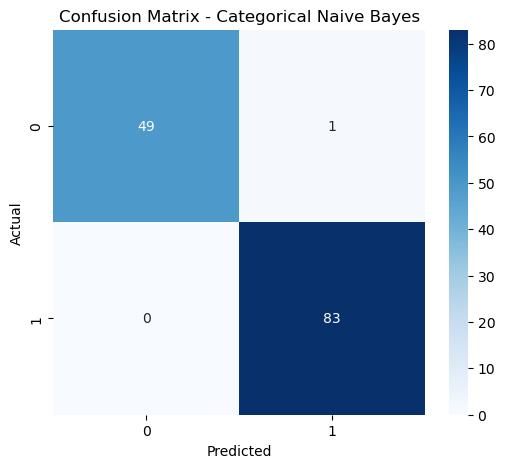

In [26]:
# ============================================================
# 26. VISUALIZE FINAL MODEL CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - " + best_model_name
)

plt.show()

In [27]:
# ============================================================
# 27. SAVE FINAL COMPARISON TABLE
# ============================================================

results_df.to_csv(
    "CKD_Model_Comparison.csv",
    index=False
)

print(
    "\nModel comparison saved as CKD_Model_Comparison.csv"
)



Model comparison saved as CKD_Model_Comparison.csv


In [28]:
# ============================================================
# 28. SAVE GRID SEARCH RESEARCH VALUES
# ============================================================

pd.DataFrame(
    grid_lr.cv_results_
).to_csv(
    "GridSearch_Logistic_Regression.csv",
    index=False
)

pd.DataFrame(
    grid_knn.cv_results_
).to_csv(
    "GridSearch_KNN.csv",
    index=False
)

pd.DataFrame(
    grid_gnb.cv_results_
).to_csv(
    "GridSearch_GaussianNB.csv",
    index=False
)

pd.DataFrame(
    grid_mnb.cv_results_
).to_csv(
    "GridSearch_MultinomialNB.csv",
    index=False
)

pd.DataFrame(
    grid_bnb.cv_results_
).to_csv(
    "GridSearch_BernoulliNB.csv",
    index=False
)

pd.DataFrame(
    grid_cnb.cv_results_
).to_csv(
    "GridSearch_CategoricalNB.csv",
    index=False
)

pd.DataFrame(
    grid_compnb.cv_results_
).to_csv(
    "GridSearch_ComplementNB.csv",
    index=False
)

pd.DataFrame(
    grid_dt.cv_results_
).to_csv(
    "GridSearch_DecisionTree.csv",
    index=False
)

pd.DataFrame(
    grid_rf.cv_results_
).to_csv(
    "GridSearch_RandomForest.csv",
    index=False
)

pd.DataFrame(
    grid_svm.cv_results_
).to_csv(
    "GridSearch_SVM.csv",
    index=False
)

print(
    "\nAll GridSearch research values have been saved."
)


All GridSearch research values have been saved.
